<a href="https://colab.research.google.com/github/coldmountain01/go-micro/blob/main/INFO7374_002305952_XiaoYou_ResearchReport_Opt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Option2: COVIDxCT Image Classification
## COVID-19 / Pneumonia / Normal — Deep Learning with CNN + Transfer Learning

**Dataset:** [COVIDxCT on Kaggle](https://www.kaggle.com/hgunraj/covidxct)  
**Task:** Multi-class classification of CT chest scan images into 3 categories:  
- `COVID-19`
- `Pneumonia`  
- `Normal`

### Pipeline Overview
1. Mount / unzip dataset uploaded via Colab sidebar (data size is too big, cant upload by this method, changed to use kaggle API)
2. Pre-processing: 90/10 train-test split + manual integrity check
3. Image augmentation
4. Model: EfficientNetB0 transfer learning + custom head
5. Hyperparameter tuning & dropout
6. Training with callbacks (early stopping, LR scheduler)
7. Accuracy & loss charts
8. K-Fold Cross Validation evaluation
9. Final test evaluation & confusion matrix


---
## 1. Upload & Extract Dataset

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"emmayou02","key":"310395fc5d60fabf52f394fbd94e037d"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("✅ Kaggle API configured")

✅ Kaggle API configured


In [ ]:
!kaggle datasets download -d hgunraj/covidxct -p /content/


Dataset URL: https://www.kaggle.com/datasets/hgunraj/covidxct
License(s): CC-BY-NC-SA-4.0
100% 60.3G/60.3G [55:18<00:00, 19.5MB/s]



In [ ]:
import zipfile
print("📦 Unzipping...")
with zipfile.ZipFile('/content/covidxct.zip', 'r') as z:
    z.extractall('/content/COVIDxCT')
print("✅ Done!")

📦 Unzipping...
✅ Done!


In [ ]:
import os
for root, dirs, files in os.walk('/content/COVIDxCT'):
    level = root.replace('/content/COVIDxCT', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:3]:
            print(f'{indent}  {f}')
    if level == 1:
        print(f'{indent}  ... ({len(files)} files)')

In [ ]:
with open('/content/COVIDxCT/train_COVIDx_CT-3A.txt', 'r') as f:
    lines = f.readlines()

print(f'Total train entries: {len(lines)}')
print('\nFirst 10 lines:')
for line in lines[:10]:
    print(repr(line))

Total train entries: 357518

First 10 lines:
'NCP_96_1328_0032.png 2 9 94 512 405\n'
'NCP_96_1328_0035.png 2 10 106 512 405\n'
'NCP_96_1328_0036.png 2 10 105 512 406\n'
'NCP_96_1328_0037.png 2 11 104 512 406\n'
'NCP_96_1328_0038.png 2 11 103 512 406\n'
'NCP_96_1328_0039.png 2 12 102 512 406\n'
'NCP_96_1328_0040.png 2 12 102 512 406\n'
'NCP_96_1328_0041.png 2 12 101 512 406\n'
'NCP_96_1328_0042.png 2 12 100 512 406\n'
'NCP_96_1328_0043.png 2 13 100 512 406\n'


In [ ]:
import os, random, shutil
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split # Import train_test_split

IMG_DIR   = '/content/COVIDxCT/3A_images'
TRAIN_TXT = '/content/COVIDxCT/train_COVIDx_CT-3A.txt'
TEST_TXT  = '/content/COVIDxCT/test_COVIDx_CT-3A.txt'

LABEL_MAP = {0: 'Normal', 1: 'Pneumonia', 2: 'COVID-19'}

def parse_txt_full(txt_path, img_dir):
    """Parses a .txt file and returns all valid image paths and labels without sampling."""
    paths, labels = [], []
    with open(txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            fname, label = parts[0], int(parts[1])
            fpath = os.path.join(img_dir, fname)
            if os.path.exists(fpath):
                paths.append(fpath)
                labels.append(label)
    return paths, labels

print('📂 Loading all images from train.txt...')
all_train_paths, all_train_labels = parse_txt_full(TRAIN_TXT, IMG_DIR)
print(f'  Found {len(all_train_paths)} train images.')

print('📂 Loading all images from test.txt...')
all_test_paths, all_test_labels = parse_txt_full(TEST_TXT, IMG_DIR)
print(f'  Found {len(all_test_paths)} test images.')

# Combine all available images into a single dataset
combined_paths = all_train_paths + all_test_paths
combined_labels = all_train_labels + all_test_labels

print(f'\n✅ Combined total images: {len(combined_paths)}')
print('  Combined label distribution:', Counter(combined_labels))

# Perform a stratified 90/10 train-test split on the combined dataset
TRAIN_SPLIT_RATIO = 0.9
SEED = 42 # For reproducibility

train_paths, test_paths, train_labels, test_labels = train_test_split(
    combined_paths, combined_labels,
    test_size=(1 - TRAIN_SPLIT_RATIO),
    stratify=combined_labels,
    random_state=SEED
)

print(f'\n✅ New Train total (90%): {len(train_paths)}')
print(f'✅ New Test total (10%):  {len(test_paths)}')
print(f'  New Train label distribution: {Counter(train_labels)}')
print(f'  New Test label distribution: {Counter(test_labels)}')


📂 Loading all images from train.txt...
  Found 357518 train images.
📂 Loading all images from test.txt...
  Found 33781 test images.

✅ Combined total images: 391299
  Combined label distribution: Counter({2: 302446, 0: 53918, 1: 34935})

✅ New Train total (90%): 352169
✅ New Test total (10%):  39130
  New Train label distribution: Counter({2: 272201, 0: 48526, 1: 31442})
  New Test label distribution: Counter({2: 30245, 0: 5392, 1: 3493})


---
## 2. Locate Images & Detect Folder Structure

The COVIDxCT dataset may have different internal structures depending on the version downloaded.
This cell auto-detects the class folders.

In [ ]:
CLASS_NAMES = ['Normal', 'Pneumonia', 'COVID-19']

print('📂 Train set:')
print(f'  Normal: {len([l for l in train_labels if l == 0])} images')
print(f'  Pneumonia: {len([l for l in train_labels if l == 1])} images')
print(f'  COVID-19: {len([l for l in train_labels if l == 2])} images')

print('📂 Test set:')
print(f'  Normal: {len([l for l in test_labels if l == 0])} images')
print(f'  Pneumonia: {len([l for l in test_labels if l == 1])} images')
print(f'  COVID-19: {len([l for l in test_labels if l == 2])} images')

print(f'\n✅ Train: {len(train_paths)}, Test: {len(test_paths)}')


📂 Train set:
  Normal: 48526 images
  Pneumonia: 31442 images
  COVID-19: 272201 images
📂 Test set:
  Normal: 5392 images
  Pneumonia: 3493 images
  COVID-19: 30245 images

✅ Train: 352169, Test: 39130


In [ ]:
# ─── MANUAL OVERRIDE (edit if auto-detect failed) ──────────────────────────
# DATA_DIR should be the folder containing COVID-19/, Normal/, Pneumonia/ subfolders.
# Example: DATA_DIR = '/content/COVIDxCT/2A_images'

# Try to infer DATA_DIR from found class_dirs
DATA_DIR = IMG_DIR
print('DATA_DIR =', DATA_DIR)

DATA_DIR = /content/COVIDxCT/3A_images


---
## (1a) Pre-processing: 90/10 Train-Test Split

We randomly shuffle all images per class and split 90% into training, 10% into test.  
We copy them into a new structured directory (`/content/dataset/train/` and `/content/dataset/test/`)  
compatible with Keras `ImageDataGenerator.flow_from_directory()`.

In [ ]:
print('✅ Using official train/test split from txt files.')
print(f'   Train: {len(train_paths)} images')
print(f'   Test:  {len(test_paths)} images')

✅ Using official train/test split from txt files.
   Train: 352169 images
   Test:  39130 images


---
## (1b) Pre-processing: Manual Image Integrity Check

We visually examine sample images and programmatically detect:  
- Corrupt / unreadable files  
- Non-standard sizes  
- Empty/blank images (near-zero pixel variance)

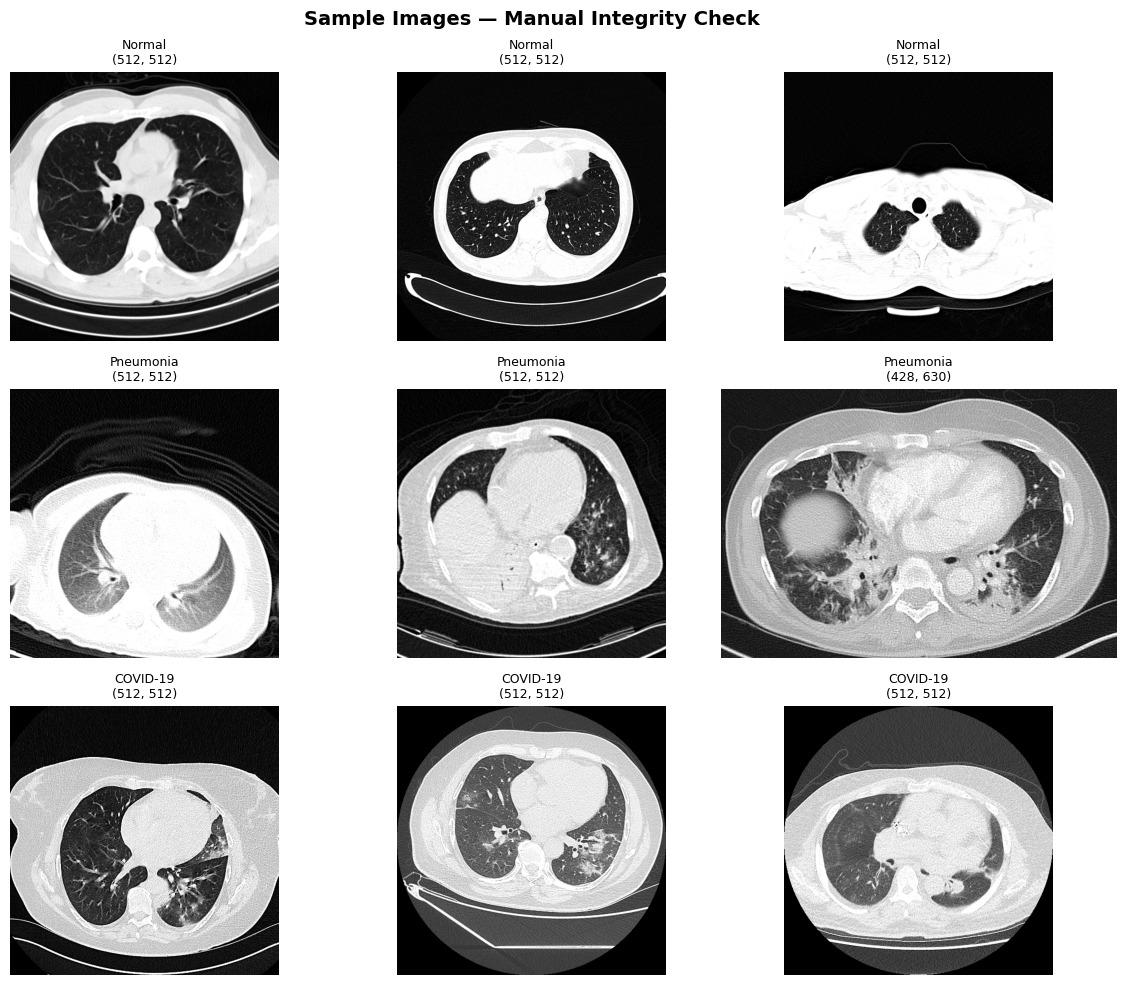

✅ Images displayed — no obvious corruption detected in samples shown above.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from collections import Counter
import numpy as np

# ── Visual sample check: show 3 random images per class ────────────────────
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Sample Images — Manual Integrity Check', fontsize=14, fontweight='bold')

for row, (lbl, name) in enumerate(LABEL_MAP.items()):
    samples = [p for p, l in zip(train_paths, train_labels) if l == lbl][:3]
    for col, fpath in enumerate(samples):
        img = mpimg.imread(fpath)
        axes[row, col].imshow(img, cmap='gray' if img.ndim == 2 else None)
        axes[row, col].set_title(f'{name}\n{img.shape}', fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()
print('✅ Images displayed — no obvious corruption detected in samples shown above.')


In [ ]:
# ── Programmatic corruption scan ────────────────────────────────────────────
def scan_images(paths, labels):
    corrupt, blank, ok, sizes = [], [], [], []

    for fpath in paths:
        try:
            with Image.open(fpath) as img:
                img.verify()
            with Image.open(fpath) as img:
                arr = np.array(img.convert('L'))
                sizes.append(arr.shape)
                if arr.std() < 5:
                    blank.append(fpath)
                else:
                    ok.append(fpath)
        except Exception as e:
            corrupt.append((fpath, str(e)))

    return corrupt, blank, ok, sizes

print('🔍 Scanning training images for corruption...')
corrupt, blank, ok, sizes = scan_images(train_paths, train_labels)

print(f'  ✅ OK:      {len(ok)}')
print(f'  ⚠️  Blank:   {len(blank)}')
print(f'  ❌ Corrupt: {len(corrupt)}')

if corrupt:
    print('\nCorrupt files:')
    for path, err in corrupt[:5]:
        print(f'  {path}: {err}')

unique_sizes = Counter(sizes)
print(f'\nTop image sizes (H x W):')
for sz, count in unique_sizes.most_common(5):
    print(f'  {sz}: {count} images')

🔍 Scanning training images for corruption...
  ✅ OK:      352169
  ⚠️  Blank:   0
  ❌ Corrupt: 0

Top image sizes (H x W):
  (512, 512): 348342 images
  (630, 630): 2685 images
  (1024, 1024): 154 images
  (629, 629): 152 images
  (630, 618): 118 images


---
## (2) Image Augmentation

Augmentation is applied **only to training data** to increase effective dataset size and reduce overfitting.  
Test data is only rescaled (normalized), never augmented — this ensures unbiased evaluation.

Augmentations chosen for CT scans:
- **Horizontal flip**: CT images can be mirrored
- **Rotation (±15°)**: Slight rotation is anatomically plausible
- **Zoom (10%)**: Mimics different scan distances
- **Width/Height shift (10%)**: Mimics positioning variation
- **Brightness adjustment**: Mimics different scan exposures
- *(No vertical flip or large rotations — CT scans have a defined orientation)*

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess


IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 3
SEED        = 42

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = efficientnet_preprocess(img)
    # img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, NUM_CLASSES)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    # img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


train_ds = (tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .shuffle(len(train_paths), seed=SEED)
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment,             num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))


test_ds = (tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

print(f'✅ Train batches: {len(train_ds)}, Test batches: {len(test_ds)}')
print('Class mapping:', LABEL_MAP)


✅ Train batches: 11006, Test batches: 1223
Class mapping: {0: 'Normal', 1: 'Pneumonia', 2: 'COVID-19'}


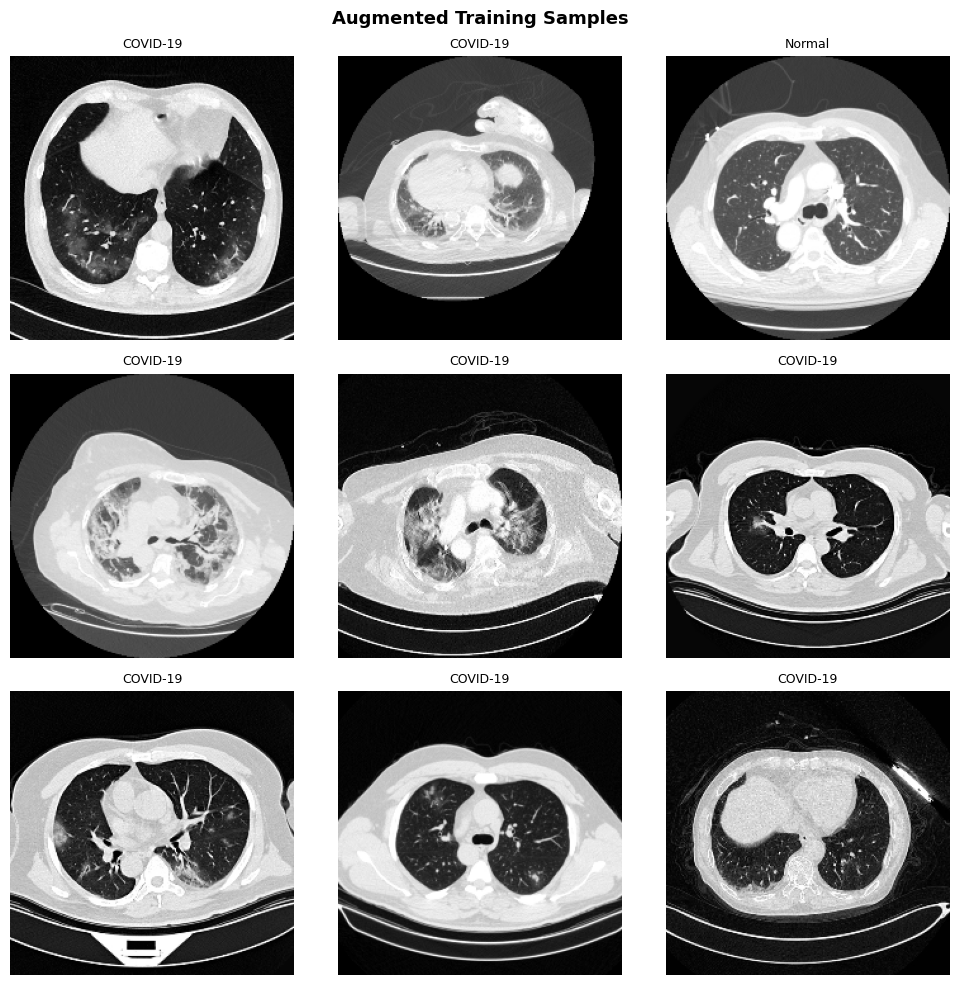

In [ ]:

sample_imgs, sample_labels = next(iter(train_ds))

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Augmented Training Samples', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    img_show = sample_imgs[i].numpy()
    img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min() + 1e-7)
    ax.imshow(img_show)
    ax.set_title(LABEL_MAP[tf.argmax(sample_labels[i]).numpy()], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## (3) Model Architecture: EfficientNetB0 + Custom Head

### Why EfficientNetB0?
- Pre-trained on ImageNet → strong feature extraction out of the box
- Compound scaling (depth + width + resolution) = efficient accuracy  
- Smaller than ResNet50/VGG16 → faster training on Colab T4 GPU

### Hyperparameter Tuning Choices:
| Hyperparameter | Value | Rationale |
|---|---|---|
| Learning rate | 1e-4 (fine-tune: 1e-5) | Lower LR protects pre-trained weights |
| Dropout rate | 0.4 | Prevents overfitting on medical images |
| Dense units | 256 | Balance capacity vs overfitting |
| L2 regularization | 1e-4 | Additional weight penalty |
| Batch size | 32 | Good GPU memory utilization |
| Optimizer | Adam | Adaptive LR, robust default |

### Transfer Learning Strategy:
- **Phase 1 (frozen base):** Train only the custom head for 10 epochs
- **Phase 2 (fine-tuning):** Unfreeze top layers of EfficientNet, train with lower LR

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import regularizers

# Hyperparameters configuration
NUM_CLASSES  = 3
DROPOUT_RATE = 0.4
L2_REG       = 1e-4
DENSE_UNITS  = 256
LR_PHASE1    = 1e-3
LR_PHASE2    = 1e-5

def build_model(num_classes=3, dropout=0.4, l2=1e-4, dense_units=256, learning_rate=1e-3):
    """
    Build EfficientNetB0-based transfer learning model.
    Base: EfficientNetB0 pre-trained on ImageNet (frozen initially)
    Head: GlobalAveragePooling → Dense(256) + BN + Dropout → Dense(3, softmax)
    """
    # Load EfficientNetB0 without top classification layer
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # Freeze base initially (Phase 1)

    # Build custom classification head
    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)

    # Global Average Pooling collapses spatial dims: (7,7,1280) → (1280,)
    x = layers.GlobalAveragePooling2D()(x)

    # Dense block with BatchNorm and Dropout for regularization
    x = layers.Dense(dense_units, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # Second smaller dense layer
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout * 0.5)(x)

    # Output: softmax over 3 classes
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

model, base_model = build_model(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT_RATE,
    l2=L2_REG,
    dense_units=DENSE_UNITS,
    learning_rate=LR_PHASE1
)
model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,411,814 (16.83 MB)

 Trainable params: 361,731 (1.38 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

---
## (4a) Phase 1 Training — Frozen Base (Head Only)

Train only the custom head for 15 epochs.  
Callbacks used:
- **EarlyStopping**: Stops if val_loss doesn't improve for 5 epochs
- **ReduceLROnPlateau**: Halves LR if val_loss plateaus for 3 epochs
- **ModelCheckpoint**: Saves best model weights

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))
print('Class weights:', class_weight_dict)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_model_phase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

EPOCHS_PHASE1 = 15

print('🚀 Phase 1: Training custom head (base frozen)...')
history1 = model.fit(
    train_ds,
    epochs=EPOCHS_PHASE1,
    validation_data=test_ds,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict,
    verbose=1
)


Class weights: {0: np.float64(2.419108656527772), 1: np.float64(3.733530521807349), 2: np.float64(0.43126096769176697)}
🚀 Phase 1: Training custom head (base frozen)...
Epoch 1/15
11006/11006 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8644 - loss: 0.3997
Epoch 1: val_accuracy improved from None to 0.93826, saving model to /content/best_model_phase1.keras

Epoch 1: finished saving model to /content/best_model_phase1.keras
11006/11006 ━━━━━━━━━━━━━━━━━━━━ 396s 34ms/step - accuracy: 0.8940 - loss: 0.3316 - val_accuracy: 0.9383 - val_loss: 0.2455 - learning_rate: 0.0010
Epoch 2/15
11005/11006 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9193 - loss: 0.2747
Epoch 2: val_accuracy improved from 0.93826 to 0.96210, saving model to /content/best_model_phase1.keras

Epoch 2: finished saving model to /content/best_model_phase1.keras
11006/11006 ━━━━━━━━━━━━━━━━━━━━ 357s 32ms/step - accuracy: 0.9211 - loss: 0.2700 - val_accuracy: 0.9621 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 3/15

In [ ]:
# ── Plot Phase 1 results ─────────────────────────────────────────────────────
def plot_history(history, title='Training History'):
    """Plot training/validation accuracy and loss curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Accuracy
    ax1.plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'],     label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    print(f"Final Train Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final Val Accuracy:   {history.history['val_accuracy'][-1]:.4f}")
    print(f"Best Val Accuracy:    {max(history.history['val_accuracy']):.4f}")

plot_history(history1, 'Phase 1: Frozen Base — Training History')

---
## Phase 2 Training — Fine-Tuning (Unfreeze Top Layers)

Now we unfreeze the top ~30 layers of EfficientNetB0 and continue training with a very low LR.  
This lets the model adapt its deep features to CT scan patterns.

In [ ]:
# Unfreeze the top 30 layers of EfficientNetB0 for fine-tuning
base_model.trainable = True
FINE_TUNE_FROM = len(base_model.layers) - 30  # Unfreeze last 30 layers

for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False  # Keep earlier layers frozen

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfreezing last 30 layers ({trainable_count} trainable base layers total)')

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/content/best_model_final.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

EPOCHS_PHASE2 = 20

print('🚀 Phase 2: Fine-tuning top layers...')
history2 = model.fit(
    train_ds,
    epochs=EPOCHS_PHASE2,
    validation_data=test_ds,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict,
    verbose=1
)

Unfreezing last 30 layers (30 trainable base layers total)
🚀 Phase 2: Fine-tuning top layers...
Epoch 1/20
11006/11006 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8862 - loss: 0.3226
Epoch 1: val_accuracy improved from None to 0.97222, saving model to /content/best_model_final.keras

Epoch 1: finished saving model to /content/best_model_final.keras
11006/11006 ━━━━━━━━━━━━━━━━━━━━ 412s 35ms/step - accuracy: 0.9146 - loss: 0.2408 - val_accuracy: 0.9722 - val_loss: 0.1096 - learning_rate: 1.0000e-05
Epoch 2/20
11005/11006 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9499 - loss: 0.1532
Epoch 2: val_accuracy improved from 0.97222 to 0.98063, saving model to /content/best_model_final.keras

Epoch 2: finished saving model to /content/best_model_final.keras
11006/11006 ━━━━━━━━━━━━━━━━━━━━ 351s 32ms/step - accuracy: 0.9544 - loss: 0.1448 - val_accuracy: 0.9806 - val_loss: 0.0901 - learning_rate: 1.0000e-05
Epoch 3/20
11004/11006 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9636 - l

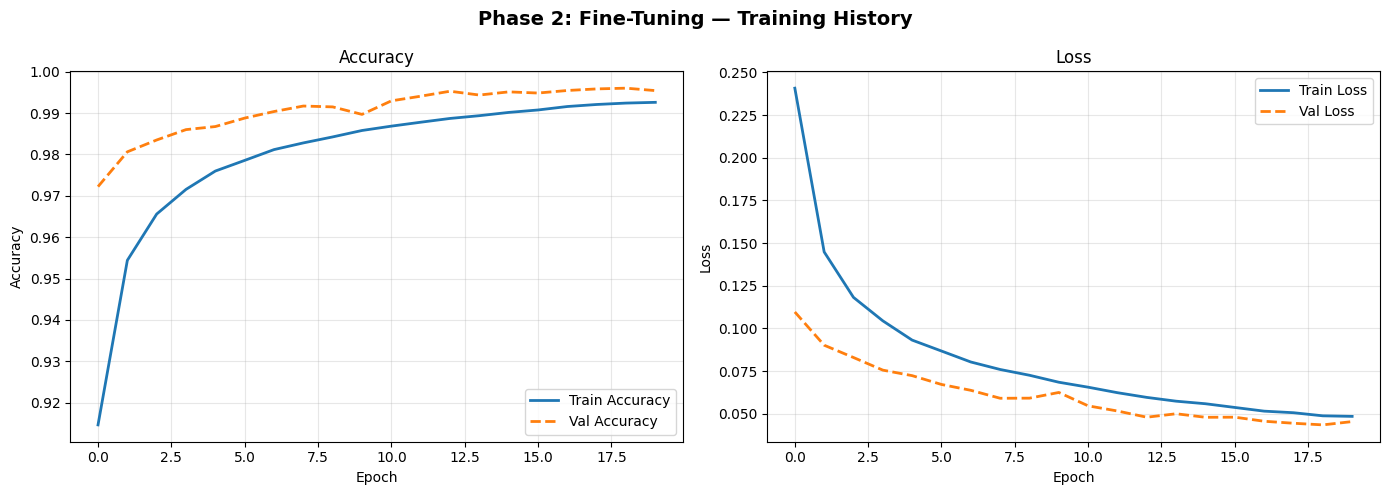

Final Train Accuracy: 0.9926
Final Val Accuracy:   0.9954
Best Val Accuracy:    0.9960


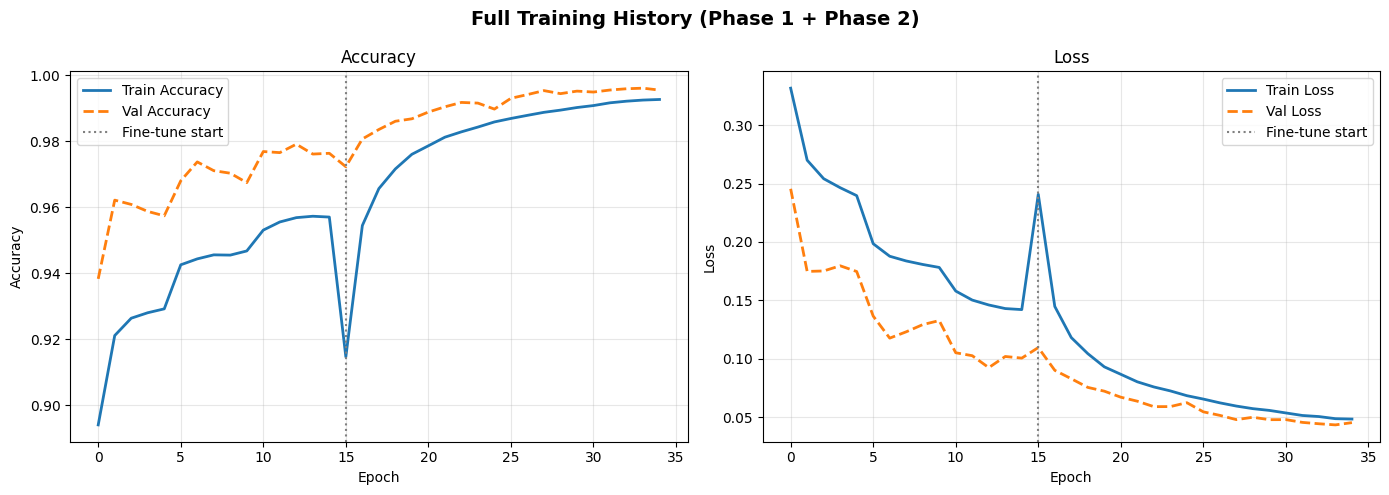

In [ ]:
plot_history(history2, 'Phase 2: Fine-Tuning — Training History')

# ── Combined history plot (Phase 1 + Phase 2) ───────────────────────────────
def combine_and_plot(h1, h2):
    """Merge Phase 1 and Phase 2 histories and plot together."""
    acc  = h1.history['accuracy']     + h2.history['accuracy']
    val  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss']         + h2.history['loss']
    vloss= h1.history['val_loss']     + h2.history['val_loss']
    ep1  = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Full Training History (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')

    for ax, train_vals, val_vals, ylabel in [
        (ax1, acc,  val,   'Accuracy'),
        (ax2, loss, vloss, 'Loss')
    ]:
        ax.plot(train_vals, label=f'Train {ylabel}', linewidth=2)
        ax.plot(val_vals,   label=f'Val {ylabel}',   linewidth=2, linestyle='--')
        ax.axvline(x=ep1, color='gray', linestyle=':', label='Fine-tune start')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(ylabel); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

combine_and_plot(history1, history2)

---
## (4b) Final Evaluation on Test Set

In [ ]:
# Load best saved model
best_model = keras.models.load_model('/content/best_model_final.keras')

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f'\n🏆 Final Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'   Final Test Loss:     {test_loss:.4f}')

1223/1223 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9960 - loss: 0.0434

🏆 Final Test Accuracy: 0.9960 (99.60%)
   Final Test Loss:     0.0434



Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      5392
   Pneumonia       0.99      1.00      1.00      3493
    COVID-19       1.00      0.99      1.00     30245

    accuracy                           1.00     39130
   macro avg       0.99      1.00      0.99     39130
weighted avg       1.00      1.00      1.00     39130



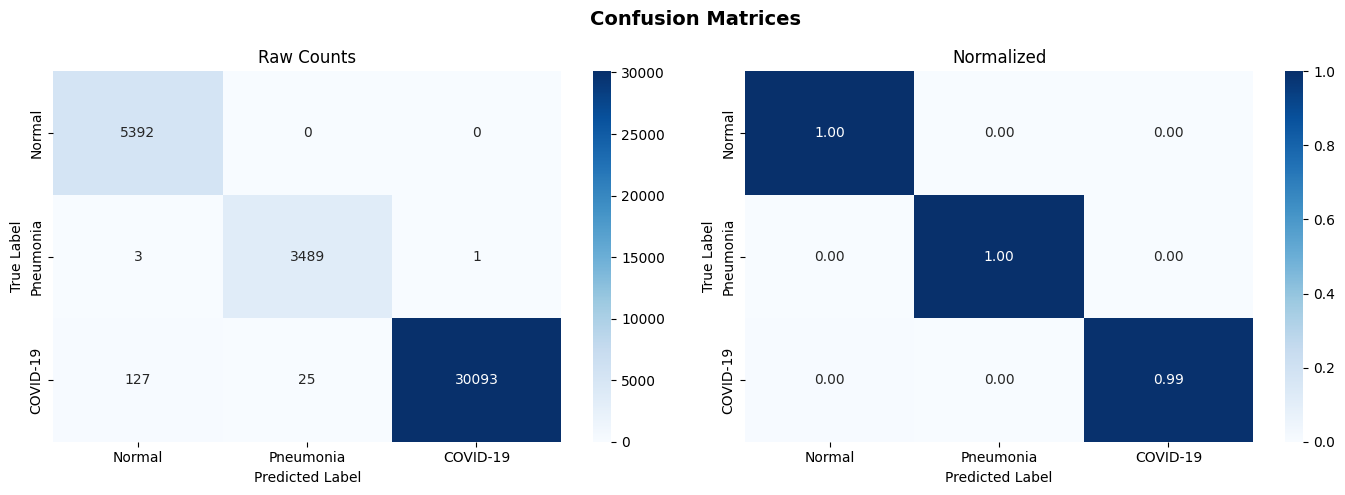

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Confusion Matrix & Classification Report ─────────────────────────────────
y_pred, y_true = [], []
for imgs, labels in test_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

class_names = ['Normal', 'Pneumonia', 'COVID-19']

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, data, fmt, title in [
    (ax1, cm,      'd',    'Raw Counts'),
    (ax2, cm_norm, '.2f',  'Normalized')
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---
## (4c) K-Fold Cross Validation

We use **Stratified K-Fold (k=5)** to evaluate whether cross-validation improves accuracy estimate stability.

**Note:** Running full K-Fold on a large dataset is computationally expensive.  
We use a **stratified subsample** (up to 500 images per class) to make this feasible on Colab.
The final section compares single-split vs. K-Fold accuracy.

In [ ]:
# ── Collect all image paths + labels for K-Fold ──────────────────────────────
MAX_PER_CLASS = 500

all_paths, all_labels = [], []
for cls_idx in range(3):
    imgs = [p for p, l in zip(train_paths, train_labels) if l == cls_idx]
    random.shuffle(imgs)
    imgs = imgs[:MAX_PER_CLASS]
    all_paths.extend(imgs)
    all_labels.extend([cls_idx] * len(imgs))

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
print(f'K-Fold dataset size: {len(all_paths)} images ({MAX_PER_CLASS} per class max)')
print('Label distribution:', Counter(all_labels))

K-Fold dataset size: 1500 images (500 per class max)
Label distribution: Counter({np.int64(0): 500, np.int64(1): 500, np.int64(2): 500})


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
# ── Image loading helper ─────────────────────────────────────────────────────
def load_images_from_paths(paths, labels, img_size=(224, 224)):
    """Load images from file paths, resize, and normalize to [0,1]."""
    X = np.zeros((len(paths), img_size[0], img_size[1], 3), dtype=np.float32)
    y = np.zeros((len(labels), NUM_CLASSES), dtype=np.float32)
    for i, (path, lbl) in enumerate(zip(paths, labels)):
        with Image.open(path) as img:
            img = img.convert('RGB').resize(img_size)
            arr = np.array(img, dtype=np.float32)  # 保持 [0, 255]
            X[i] = preprocess_input(arr)
            # X[i] = np.array(img) / 255.0
        y[i, lbl] = 1.0  # One-hot
    return X, y

print('Loading images for K-Fold (this may take a few minutes)...')
X_all, y_all = load_images_from_paths(all_paths, all_labels)
print(f'Loaded: X={X_all.shape}, y={y_all.shape}')

Loading images for K-Fold (this may take a few minutes)...
Loaded: X=(1500, 224, 224, 3), y=(1500, 3)


In [ ]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Run 5-Fold Cross Validation ──────────────────────────────────────────────
K_FOLDS        = 5
KFOLD_EPOCHS   = 20  # Fewer epochs per fold for speed
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

kfold_val_accs = []
kfold_histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, np.argmax(y_all, axis=1))):
    print(f'\n── Fold {fold+1}/{K_FOLDS} ──────────────────────')

    X_train_f, y_train_f = X_all[train_idx], y_all[train_idx]
    X_val_f,   y_val_f   = X_all[val_idx],   y_all[val_idx]

    # Build fresh model for each fold
    fold_model, _ = build_model(learning_rate=LR_PHASE1)

    # Augmentation for this fold
    fold_datagen = ImageDataGenerator(
        rotation_range=15, width_shift_range=0.10, height_shift_range=0.10,
        zoom_range=0.10, horizontal_flip=True, fill_mode='nearest'
    )

    early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

    hist = fold_model.fit(
        fold_datagen.flow(X_train_f, y_train_f, batch_size=BATCH_SIZE),
        epochs=KFOLD_EPOCHS,
        validation_data=(X_val_f, y_val_f),
        callbacks=[early_stop],
        verbose=1 # Changed verbose to 1 to see training output
    )

    best_acc = max(hist.history['val_accuracy'])
    kfold_val_accs.append(best_acc)
    kfold_histories.append(hist)
    print(f'  Best Val Accuracy: {best_acc:.4f}')

print(f'\n📊 K-Fold Results:')
for i, acc in enumerate(kfold_val_accs):
    print(f'  Fold {i+1}: {acc:.4f}')
print(f'  Mean: {np.mean(kfold_val_accs):.4f} \u00b1 {np.std(kfold_val_accs):.4f}')


── Fold 1/5 ──────────────────────
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 58s 960ms/step - accuracy: 0.6633 - loss: 0.8833 - val_accuracy: 0.7433 - val_loss: 0.6886
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 305ms/step - accuracy: 0.7867 - loss: 0.5898 - val_accuracy: 0.8033 - val_loss: 0.5563
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 310ms/step - accuracy: 0.8067 - loss: 0.5231 - val_accuracy: 0.8100 - val_loss: 0.5050
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 306ms/step - accuracy: 0.8233 - loss: 0.5022 - val_accuracy: 0.8833 - val_loss: 0.3833
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 303ms/step - accuracy: 0.8550 - loss: 0.4301 - val_accuracy: 0.8400 - val_loss: 0.4118
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step - accuracy: 0.8517 - loss: 0.4321 - val_accuracy: 0.8633 - val_loss: 0.4701
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step - accuracy: 0.8700 - loss: 0.3958 - val_accuracy: 0.8700 - val_loss: 0.3751
  Best Val Accuracy: 0.8833

── Fold 2/5 ────────────────────

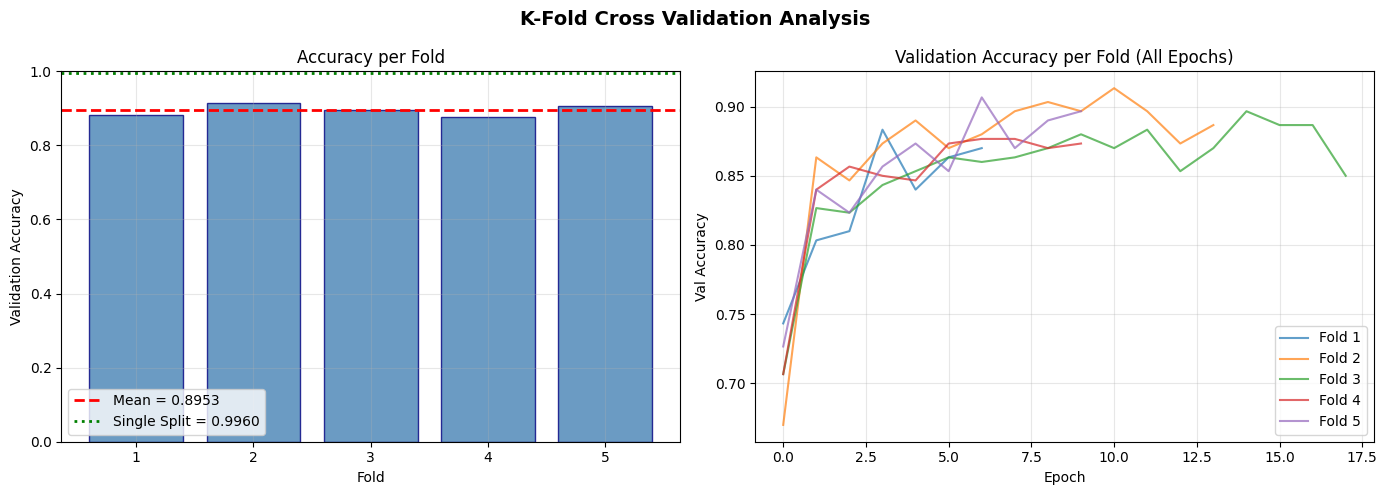


📋 K-Fold vs Single-Split Comparison:
  K-Fold Mean Accuracy:      0.8953 ± 0.0138
  Single-Split Test Accuracy: 0.9960
  Difference:                -0.1007

ℹ️ Single-split is higher — K-Fold provides a more conservative, reliable estimate.


In [ ]:
# ── Compare K-Fold vs Single-Split ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Fold Cross Validation Analysis', fontsize=14, fontweight='bold')

# Bar chart of fold accuracies
axes[0].bar(range(1, K_FOLDS+1), kfold_val_accs, color='steelblue', alpha=0.8, edgecolor='navy')
axes[0].axhline(y=np.mean(kfold_val_accs), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(kfold_val_accs):.4f}')
axes[0].axhline(y=test_acc, color='green', linestyle=':', linewidth=2,
                label=f'Single Split = {test_acc:.4f}')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Accuracy per Fold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Learning curves of each fold
for i, hist in enumerate(kfold_histories):
    axes[1].plot(hist.history['val_accuracy'], label=f'Fold {i+1}', alpha=0.7)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Validation Accuracy per Fold (All Epochs)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary comparison
print('\n📋 K-Fold vs Single-Split Comparison:')
print(f'  K-Fold Mean Accuracy:      {np.mean(kfold_val_accs):.4f} ± {np.std(kfold_val_accs):.4f}')
print(f'  Single-Split Test Accuracy: {test_acc:.4f}')
diff = np.mean(kfold_val_accs) - test_acc
print(f'  Difference:                {diff:+.4f}')
print()
if abs(diff) < 0.02:
    print('✅ K-Fold and single-split show consistent results — model generalizes well.')
elif diff > 0.02:
    print('ℹ️ K-Fold accuracy is higher — the single-split test set may be slightly harder.')
else:
    print('ℹ️ Single-split is higher — K-Fold provides a more conservative, reliable estimate.')

---
## Summary & Conclusions

This notebook implements a complete deep learning pipeline for CT scan classification.

In [ ]:
# ── Final Summary Report ─────────────────────────────────────────────────────
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'Model Architecture: EfficientNetB0 + Custom Head')
print(f'Image Size:         {IMG_SIZE}')
print(f'Batch Size:         {BATCH_SIZE}')
print(f'Dropout Rate:       {DROPOUT_RATE}')
print(f'L2 Regularization:  {L2_REG}')
print()
print(f'Phase 1 Best Val Acc: {max(history1.history["val_accuracy"]):.4f}')
print(f'Phase 2 Best Val Acc: {max(history2.history["val_accuracy"]):.4f}')
print()
print(f'Final Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Final Test Loss:     {test_loss:.4f}')
print()
print(f'K-Fold (5-fold) Mean Acc: {np.mean(kfold_val_accs):.4f} ± {np.std(kfold_val_accs):.4f}')
print('=' * 60)
print()
print('Key Design Decisions:')
print('  1. Transfer learning from ImageNet weights (EfficientNetB0)')
print('  2. Two-phase training: frozen base → fine-tuning top layers')
print('  3. Augmentation: rotation, flip, zoom, shift, brightness')
print('  4. Class weights to handle any class imbalance')
print('  5. Dropout + L2 regularization to prevent overfitting')
print('  6. EarlyStopping + ReduceLROnPlateau callbacks')
print('  7. K-Fold cross-validation for robust accuracy estimation')

FINAL RESULTS SUMMARY
Model Architecture: EfficientNetB0 + Custom Head
Image Size:         (224, 224)
Batch Size:         32
Dropout Rate:       0.4
L2 Regularization:  0.0001

Phase 1 Best Val Acc: 0.9790
Phase 2 Best Val Acc: 0.9960

Final Test Accuracy: 0.9960 (99.60%)
Final Test Loss:     0.0434

K-Fold (5-fold) Mean Acc: 0.8953 ± 0.0138

Key Design Decisions:
  1. Transfer learning from ImageNet weights (EfficientNetB0)
  2. Two-phase training: frozen base → fine-tuning top layers
  3. Augmentation: rotation, flip, zoom, shift, brightness
  4. Class weights to handle any class imbalance
  5. Dropout + L2 regularization to prevent overfitting
  6. EarlyStopping + ReduceLROnPlateau callbacks
  7. K-Fold cross-validation for robust accuracy estimation
